In [36]:
import os
import json
import numpy as np
import pandas as pd
from datetime import datetime

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

import matplotlib.pyplot as plt

from sklearn.model_selection import KFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [37]:
# -----------------------------
# 1) CONFIG
# -----------------------------
DATA_PATH = "/Users/doreennoldajehu-appiah/Desktop/DEE_NCAT_Work/PhD.Docs/COURSES_semesters/SPRING2026/Deep_Learning/ImputedData_NAMED_FLI.csv"

# Output location (everything saved here)
RUN_ID = datetime.now().strftime("%Y%m%d_%H%M%S")
OUTPUT_DIR = os.path.abspath(f"./mixture_transformer_run_{RUN_ID}")
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Outcomes to model (edit based on what's in your dataset)
OUTCOME_COLS = [
    "FLI", "ALT", "AST", "GGT", "ALP", "TotalBilirubin"
]

# Columns to drop if they exist (IDs / survey design)
DROP_FROM_FEATURES = ["seqn", "sdmvpsu", "sdmvstra", "wtmec2yr"]

# Whether to include covariates (if present) as features
USE_COVARIATES = True
COVARIATE_COLS = [
    "age", "Age", "Gender", "Sex", "Ethnicity", "BMI", "WaistCircumference",
    "smoke", "alcohol", "income", "Education"
]

# CV and training
N_SPLITS = 5
RANDOM_STATE = 42
BATCH_SIZE = 64
EPOCHS = 30
LR = 1e-3

# Transformer params
EMBED_DIM = 32
N_HEADS = 4
N_LAYERS = 2
DROPOUT = 0.1

# MLP baseline params
MLP_HIDDEN = [256, 128, 64]
MLP_DROPOUT = 0.1

# Attention plotting: show top-k features for readability
ATTN_TOPK = 30

# Save figures resolution
FIG_DPI = 300

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"OUTPUT_DIR = {OUTPUT_DIR}")

OUTPUT_DIR = /Users/doreennoldajehu-appiah/Desktop/DEE_NCAT_Work/PhD.Docs/COURSES_semesters/SPRING2026/Deep_Learning/mixture_transformer_run_20260124_223125


In [38]:
# -----------------------------
# 2) HELPERS: I/O
# -----------------------------
def save_text(path, text):
    os.makedirs(os.path.dirname(path), exist_ok=True)
    with open(path, "w", encoding="utf-8") as f:
        f.write(text)

def save_json(path, obj):
    os.makedirs(os.path.dirname(path), exist_ok=True)
    with open(path, "w", encoding="utf-8") as f:
        json.dump(obj, f, indent=2)

def save_df(path, df):
    os.makedirs(os.path.dirname(path), exist_ok=True)
    df.to_csv(path, index=False)

def ieee_caption(title, what, notes):
    # Simple caption style that reads like IEEE figure captions
    return f"{title}. {what} {notes}".strip()
def clean_Xy_for_outcome(X, y, outcome_name, save_dir):
    """
    Cleans X and y to avoid NaN/Inf causing nan losses and sklearn metric crashes.
    - Replaces +/-inf with NaN
    - Imputes X NaNs with column medians
    - Drops rows where y is not finite
    - Drops any remaining rows where X is not finite
    Saves a small report to save_dir/data_cleaning_report.json
    """
    X = X.copy().astype(float)
    y = y.copy().astype(float)

    # Replace inf with NaN
    X[~np.isfinite(X)] = np.nan
    y[~np.isfinite(y)] = np.nan

    # Impute X NaNs with column medians
    col_medians = np.nanmedian(X, axis=0)
    # If any column is all-NaN, median becomes NaN -> replace with 0
    col_medians = np.where(np.isfinite(col_medians), col_medians, 0.0)

    nan_rows, nan_cols = np.where(np.isnan(X))
    if len(nan_rows) > 0:
        X[nan_rows, nan_cols] = col_medians[nan_cols]

    # Keep only rows with finite y and finite X
    y_ok = np.isfinite(y)
    X_ok = np.isfinite(X).all(axis=1)
    keep = y_ok & X_ok

    report = {
        "outcome": outcome_name,
        "rows_total": int(len(y)),
        "rows_kept": int(keep.sum()),
        "rows_dropped": int((~keep).sum())
    }
    save_json(os.path.join(save_dir, "data_cleaning_report.json"), report)

    return X[keep], y[keep]


In [39]:
# -----------------------------
# 3) LOAD DATA
# -----------------------------
df = pd.read_csv("/Users/doreennoldajehu-appiah/Desktop/DEE_NCAT_Work/PhD.Docs/COURSES_semesters/SPRING2026/Deep_Learning/ImputedData_NAMED_FLI.csv")

# Use numeric columns only (keeps modeling stable)
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
df = df[numeric_cols].copy()

# Keep only outcomes that exist
OUTCOME_COLS = [c for c in OUTCOME_COLS if c in df.columns]
if len(OUTCOME_COLS) == 0:
    raise ValueError("None of the liver outcomes were found in the dataset after numeric filtering.")
print("Liver outcomes found:", OUTCOME_COLS)

# Features = all numeric cols except outcomes
feature_cols = [c for c in df.columns if c not in OUTCOME_COLS]
feature_cols = [c for c in feature_cols if c not in DROP_FROM_FEATURES]
if not USE_COVARIATES:
    feature_cols = [c for c in feature_cols if c not in COVARIATE_COLS]

if len(feature_cols) == 0:
    raise ValueError("No feature columns left after filtering. Check OUTCOME_COLS/DROP lists.")

X_all = df[feature_cols].values.astype(float)

save_text(os.path.join(OUTPUT_DIR, "feature_list.txt"), "\n".join(feature_cols))
save_text(os.path.join(OUTPUT_DIR, "outcome_list.txt"), "\n".join(OUTCOME_COLS))

print(f"Using {len(feature_cols)} features. First 10 features: {feature_cols[:10]}")

Liver outcomes found: ['FLI', 'ALT', 'AST', 'GGT', 'ALP', 'TotalBilirubin']
Using 54 features. First 10 features: ['Arsenic', 'Mercury', 'Barium', 'Cobalt', 'Cesium', 'Molybdenum', 'Lead', 'Antimony', 'Tin', 'Strontium']


In [40]:
# 4) DATASET
# -----------------------------
class TabularDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

In [41]:
# 5) MODELS
# -----------------------------
class MLPRegressor(nn.Module):
    def __init__(self, n_features, hidden_sizes=(256, 128, 64), dropout=0.1):
        super().__init__()
        layers = []
        in_dim = n_features
        for h in hidden_sizes:
            layers.append(nn.Linear(in_dim, h))
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(dropout))
            in_dim = h
        layers.append(nn.Linear(in_dim, 1))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x).squeeze(-1)


class AttnEncoderLayer(nn.Module):
    """
    Custom encoder layer that returns attention weights for interpretability.
    """
    def __init__(self, d_model, nhead, dim_feedforward=128, dropout=0.1):
        super().__init__()
        self.mha = nn.MultiheadAttention(
            embed_dim=d_model,
            num_heads=nhead,
            dropout=dropout,
            batch_first=True
        )
        self.ff = nn.Sequential(
            nn.Linear(d_model, dim_feedforward),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(dim_feedforward, d_model),
        )
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.drop = nn.Dropout(dropout)

    def forward(self, x):
        attn_out, attn_w = self.mha(x, x, x, need_weights=True, average_attn_weights=False)
        x = self.norm1(x + self.drop(attn_out))
        ff_out = self.ff(x)
        x = self.norm2(x + self.drop(ff_out))
        return x, attn_w


class TabularTransformerWithAttn(nn.Module):
    """
    Each feature is a token. Returns:
      pred: [batch]
      attn_layers: list of [batch, heads, tokens, tokens]
    """
    def __init__(self, n_features, embed_dim=32, n_heads=4, n_layers=2, dropout=0.1):
        super().__init__()
        self.feature_embedding = nn.Linear(1, embed_dim)
        self.layers = nn.ModuleList([
            AttnEncoderLayer(embed_dim, n_heads, dim_feedforward=128, dropout=dropout)
            for _ in range(n_layers)
        ])
        self.regressor = nn.Sequential(
            nn.Linear(embed_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 1)
        )

    def forward(self, x):
        x = x.unsqueeze(-1)            # [B, T, 1]
        x = self.feature_embedding(x)  # [B, T, D]

        attn_weights_layers = []
        for layer in self.layers:
            x, attn_w = layer(x)
            attn_weights_layers.append(attn_w)

        pooled = x.mean(dim=1)         # [B, D]
        pred = self.regressor(pooled).squeeze(-1)
        return pred, attn_weights_layers


In [42]:
# 6) TRAIN / EVAL
# -----------------------------
def train_model(model, train_loader, epochs=30, lr=1e-3, is_transformer=False):
    model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.MSELoss()

    for epoch in range(epochs):
        model.train()
        epoch_loss = 0.0

        for Xb, yb in train_loader:
            Xb = Xb.to(device)
            yb = yb.to(device)

            optimizer.zero_grad()
            if is_transformer:
                preds, _ = model(Xb)
            else:
                preds = model(Xb)

            loss = criterion(preds, yb)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()

        epoch_loss /= max(1, len(train_loader))
        if (epoch + 1) % 10 == 0 or epoch == 0:
            print(f"    Epoch {epoch+1:02d}/{epochs} | Train MSE: {epoch_loss:.4f}")


def predict_and_metrics(model, test_loader, is_transformer=False):
    """
    Returns:
      y_true, y_pred, rmse, mae, r2, attn_matrix (or None)
    Note: attn_matrix is averaged over layers + batch + heads + batches (summed then effectively averaged).
    """
    model.eval()
    y_true, y_pred = [], []
    all_attn = None
    n_batches = 0

    with torch.no_grad():
        for Xb, yb in test_loader:
            Xb = Xb.to(device)

            if is_transformer:
                preds, attn_layers = model(Xb)
                # attn_layers: list of [B, H, T, T]
                attn_stack = torch.stack(attn_layers, dim=0)   # [L, B, H, T, T]
                attn_avg = attn_stack.mean(dim=(0, 1, 2))      # [T, T]
                if all_attn is None:
                    all_attn = attn_avg.cpu().numpy()
                else:
                    all_attn += attn_avg.cpu().numpy()
                n_batches += 1
            else:
                preds = model(Xb)

            y_true.extend(yb.numpy())
            y_pred.extend(preds.detach().cpu().numpy())

    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    r2   = r2_score(y_true, y_pred)

    # average attention across test batches
    if is_transformer and all_attn is not None and n_batches > 0:
        all_attn = all_attn / float(n_batches)

    return y_true, y_pred, rmse, mae, r2, all_attn

In [43]:
# 7) PLOTS (IEEE-ready)
# -----------------------------
def plot_pred_vs_true(y_true, y_pred, out_png, caption_txt_path, title_prefix):
    plt.figure()
    plt.scatter(y_true, y_pred)
    plt.xlabel("True outcome")
    plt.ylabel("Predicted outcome")
    plt.title(f"{title_prefix}: Predicted vs True")
    plt.tight_layout()
    plt.savefig(out_png, dpi=FIG_DPI)
    plt.close()

    save_text(caption_txt_path, ieee_caption(
        title="Fig. Predicted vs. true outcomes",
        what="Scatter plot comparing model predictions against observed values.",
        notes="Points closer to the diagonal indicate improved predictive accuracy."
    ))

def plot_residuals(y_true, y_pred, out_png, caption_txt_path, title_prefix):
    resid = y_true - y_pred
    plt.figure()
    plt.scatter(y_pred, resid)
    plt.axhline(0, linewidth=1)
    plt.xlabel("Predicted outcome")
    plt.ylabel("Residual (true - predicted)")
    plt.title(f"{title_prefix}: Residual plot")
    plt.tight_layout()
    plt.savefig(out_png, dpi=FIG_DPI)
    plt.close()

    save_text(caption_txt_path, ieee_caption(
        title="Fig. Residual analysis",
        what="Residuals versus fitted values to assess systematic error patterns.",
        notes="A random spread around zero suggests limited bias and good calibration."
    ))

def plot_attention_heatmap(attn_matrix, feature_names, out_png, caption_txt_path, title_prefix, topk=30):
    if attn_matrix is None:
        return

    # choose top-k tokens by total attention mass
    scores = attn_matrix.sum(axis=0) + attn_matrix.sum(axis=1)
    idx = np.argsort(scores)[::-1][:min(topk, len(scores))]

    A = attn_matrix[np.ix_(idx, idx)]
    labels = [feature_names[i] for i in idx]

    plt.figure(figsize=(10, 8))
    plt.imshow(A, aspect="auto")
    plt.colorbar()
    plt.xticks(np.arange(len(labels)), labels, rotation=90, fontsize=7)
    plt.yticks(np.arange(len(labels)), labels, fontsize=7)
    plt.title(f"{title_prefix}: Attention heatmap (Top {len(labels)})")
    plt.tight_layout()
    plt.savefig(out_png, dpi=FIG_DPI)
    plt.close()

    save_text(caption_txt_path, ieee_caption(
        title="Fig. Attention-based interaction map",
        what="Heatmap of averaged self-attention weights between exposure tokens.",
        notes="Higher weights indicate stronger learned dependencies that may reflect mixture interactions."
    ))

In [44]:
# 8) K-FOLD CV RUN (one model per outcome)
# -----------------------------
kf = KFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)
all_metrics_rows = []

for outcome in OUTCOME_COLS:
    print("\n===================================================")
    print(f"Liver Outcome: {outcome}")
    print("===================================================")

    y_all = df[outcome].values.astype(float)
        # NEW: clean X and y for this outcome (fixes NaN/Inf causing nan loss + metric crash)
    X_clean, y_clean = clean_Xy_for_outcome(X_all, y_all, outcome, outcome_dir)

    if len(y_clean) < N_SPLITS:
        print(f"Skipping {outcome}: not enough clean rows for {N_SPLITS}-fold CV.")
        continue

    outcome_dir = os.path.join(OUTPUT_DIR, f"outcome={outcome}")
    os.makedirs(outcome_dir, exist_ok=True)

    fold_rows = []

    # NEW: collect predictions across folds for this outcome
    preds_all_folds = []

    for fold, (train_idx, test_idx) in enumerate(kf.split(X_clean), start=1):
        print(f"\n  Fold {fold}/{N_SPLITS}")
        fold_dir = os.path.join(outcome_dir, f"fold={fold}")
        os.makedirs(fold_dir, exist_ok=True)

        # Split
        X_train_raw, X_test_raw = X_clean[train_idx], X_clean[test_idx]
        y_train, y_test = y_clean[train_idx], y_clean[test_idx]
        # Scale (fit on train, apply to test)
        scaler = StandardScaler()
        X_train = scaler.fit_transform(X_train_raw)
        X_test  = scaler.transform(X_test_raw)

        # Save datasets
        train_df = pd.DataFrame(X_train, columns=feature_cols)
        train_df[outcome] = y_train
        test_df = pd.DataFrame(X_test, columns=feature_cols)
        test_df[outcome] = y_test

        save_df(os.path.join(fold_dir, "train_scaled.csv"), train_df)
        save_df(os.path.join(fold_dir, "test_scaled.csv"), test_df)
        save_json(os.path.join(fold_dir, "split_indices.json"), {
            "train_idx": train_idx.tolist(),
            "test_idx": test_idx.tolist()
        })

        # DataLoaders
        train_loader = DataLoader(TabularDataset(X_train, y_train), batch_size=BATCH_SIZE, shuffle=True)
        test_loader  = DataLoader(TabularDataset(X_test, y_test), batch_size=BATCH_SIZE, shuffle=False)

        # A) Transformer
        tfm = TabularTransformerWithAttn(
            n_features=X_train.shape[1],
            embed_dim=EMBED_DIM,
            n_heads=N_HEADS,
            n_layers=N_LAYERS,
            dropout=DROPOUT
        )
        train_model(tfm, train_loader, epochs=EPOCHS, lr=LR, is_transformer=True)
        y_true_t, y_pred_t, rmse_t, mae_t, r2_t, attn = predict_and_metrics(tfm, test_loader, is_transformer=True)

        save_df(
            os.path.join(fold_dir, "predictions_transformer.csv"),
            pd.DataFrame({"y_true": y_true_t, "y_pred_transformer": y_pred_t})
        )

        if attn is not None:
            pd.DataFrame(attn, index=feature_cols, columns=feature_cols).to_csv(
                os.path.join(fold_dir, "attention_matrix_full.csv")
            )

        plot_pred_vs_true(
            y_true_t, y_pred_t,
            os.path.join(fold_dir, "fig_pred_vs_true_transformer.png"),
            os.path.join(fold_dir, "fig_pred_vs_true_transformer_caption.txt"),
            f"{outcome} (Transformer, fold {fold})"
        )
        plot_residuals(
            y_true_t, y_pred_t,
            os.path.join(fold_dir, "fig_residuals_transformer.png"),
            os.path.join(fold_dir, "fig_residuals_transformer_caption.txt"),
            f"{outcome} (Transformer, fold {fold})"
        )
        plot_attention_heatmap(
            attn, feature_cols,
            os.path.join(fold_dir, "fig_attention_heatmap_topk.png"),
            os.path.join(fold_dir, "fig_attention_heatmap_topk_caption.txt"),
            f"{outcome} (Transformer, fold {fold})",
            topk=ATTN_TOPK
        )

        # B) MLP baseline (same inputs)
        mlp = MLPRegressor(
            n_features=X_train.shape[1],
            hidden_sizes=tuple(MLP_HIDDEN),
            dropout=MLP_DROPOUT
        )
        train_model(mlp, train_loader, epochs=EPOCHS, lr=LR, is_transformer=False)
        y_true_m, y_pred_m, rmse_m, mae_m, r2_m, _ = predict_and_metrics(mlp, test_loader, is_transformer=False)

        save_df(
            os.path.join(fold_dir, "predictions_mlp.csv"),
            pd.DataFrame({"y_true": y_true_m, "y_pred_mlp": y_pred_m})
        )

        plot_pred_vs_true(
            y_true_m, y_pred_m,
            os.path.join(fold_dir, "fig_pred_vs_true_mlp.png"),
            os.path.join(fold_dir, "fig_pred_vs_true_mlp_caption.txt"),
            f"{outcome} (MLP, fold {fold})"
        )
        plot_residuals(
            y_true_m, y_pred_m,
            os.path.join(fold_dir, "fig_residuals_mlp.png"),
            os.path.join(fold_dir, "fig_residuals_mlp_caption.txt"),
            f"{outcome} (MLP, fold {fold})"
        )

        # NEW: merged predictions for this fold (Transformer + MLP)
        fold_pred_df = pd.DataFrame({
            "fold": np.full(len(y_true_t), fold, dtype=int),
            "y_true": y_true_t,
            "y_pred_transformer": y_pred_t,
            "y_pred_mlp": y_pred_m
        })
        preds_all_folds.append(fold_pred_df)

        # Metrics rows
        rows = [
            {"outcome": outcome, "fold": fold, "model": "Transformer", "RMSE": rmse_t, "MAE": mae_t, "R2": r2_t},
            {"outcome": outcome, "fold": fold, "model": "MLP",         "RMSE": rmse_m, "MAE": mae_m, "R2": r2_m},
        ]
        fold_rows.extend(rows)
        all_metrics_rows.extend(rows)

        print(f"    Transformer: RMSE={rmse_t:.4f} MAE={mae_t:.4f} R2={r2_t:.4f}")
        print(f"    MLP        : RMSE={rmse_m:.4f} MAE={mae_m:.4f} R2={r2_m:.4f}")

    # Save outcome metrics
    outcome_metrics_df = pd.DataFrame(fold_rows)
    save_df(os.path.join(outcome_dir, "metrics_by_fold.csv"), outcome_metrics_df)

    summary = outcome_metrics_df.groupby("model")[["RMSE", "MAE", "R2"]].agg(["mean", "std"]).reset_index()
    summary.columns = ["_".join([c for c in col if c]) for col in summary.columns.values]
    save_df(os.path.join(outcome_dir, "metrics_summary.csv"), summary)

    # NEW: save merged predictions across all folds for this outcome
    preds_all_folds_df = pd.concat(preds_all_folds, ignore_index=True)
    merged_path = os.path.join(outcome_dir, f"predictions_all_folds_{outcome}.csv")
    save_df(merged_path, preds_all_folds_df)

    print("\nOutcome summary (mean ± std):")
    print(summary)
    print(f"Saved merged predictions across folds: {merged_path}")


# Save global metrics
all_metrics_df = pd.DataFrame(all_metrics_rows)
save_df(os.path.join(OUTPUT_DIR, "ALL_metrics_by_fold.csv"), all_metrics_df)

global_summary = (
    all_metrics_df
    .groupby(["outcome", "model"])[["RMSE", "MAE", "R2"]]
    .agg(["mean", "std"])
    .reset_index()
)
global_summary.columns = ["_".join([c for c in col if c]) for col in global_summary.columns.values]
save_df(os.path.join(OUTPUT_DIR, "ALL_metrics_summary.csv"), global_summary)

print("\n===================================================")
print("DONE. Saved everything to:")
print(OUTPUT_DIR)
print("Key files:")
print(" - ALL_metrics_by_fold.csv")
print(" - ALL_metrics_summary.csv")
print(" - outcome=*/fold=*/train_scaled.csv, test_scaled.csv")
print(" - outcome=*/fold=*/fig_*.png + caption .txt")
print(" - outcome=*/predictions_all_folds_<OUTCOME>.csv  (NEW)")
print("===================================================")


Liver Outcome: FLI

  Fold 1/5
    Epoch 01/30 | Train MSE: 3043.1653
    Epoch 10/30 | Train MSE: 1110.5167
    Epoch 20/30 | Train MSE: 1084.7542
    Epoch 30/30 | Train MSE: 1071.2406
    Epoch 01/30 | Train MSE: 2234.6014
    Epoch 10/30 | Train MSE: 246.1173
    Epoch 20/30 | Train MSE: 142.5588
    Epoch 30/30 | Train MSE: 123.5892
    Transformer: RMSE=33.4106 MAE=29.8145 R2=0.0373
    MLP        : RMSE=12.1972 MAE=8.6104 R2=0.8717

  Fold 2/5
    Epoch 01/30 | Train MSE: 3023.1044
    Epoch 10/30 | Train MSE: 1096.2870
    Epoch 20/30 | Train MSE: 1081.2762
    Epoch 30/30 | Train MSE: 1077.7509
    Epoch 01/30 | Train MSE: 2110.5641
    Epoch 10/30 | Train MSE: 234.5718
    Epoch 20/30 | Train MSE: 143.0533
    Epoch 30/30 | Train MSE: 117.3823
    Transformer: RMSE=33.4429 MAE=29.8037 R2=0.0667
    MLP        : RMSE=13.8045 MAE=9.0408 R2=0.8410

  Fold 3/5
    Epoch 01/30 | Train MSE: 3094.7258
    Epoch 10/30 | Train MSE: 1113.2010
    Epoch 20/30 | Train MSE: 1102.8521
   

    Epoch 01/30 | Train MSE: 3046.7865
    Epoch 10/30 | Train MSE: 2497.3975
    Epoch 20/30 | Train MSE: 2639.3153
    Epoch 30/30 | Train MSE: 2489.5844
    Epoch 01/30 | Train MSE: 2851.5150
    Epoch 10/30 | Train MSE: 1831.2805
    Epoch 20/30 | Train MSE: 594.9817
    Epoch 30/30 | Train MSE: 401.0259
    Transformer: RMSE=37.1535 MAE=15.8715 R2=0.0028
    MLP        : RMSE=31.6567 MAE=13.9288 R2=0.2761

  Fold 2/5
    Epoch 01/30 | Train MSE: 2300.0403
    Epoch 10/30 | Train MSE: 1761.6523
    Epoch 20/30 | Train MSE: 1757.7381
    Epoch 30/30 | Train MSE: 1754.0125
    Epoch 01/30 | Train MSE: 2064.3793
    Epoch 10/30 | Train MSE: 1485.8789
    Epoch 20/30 | Train MSE: 487.0818
    Epoch 30/30 | Train MSE: 376.2463
    Transformer: RMSE=65.5030 MAE=19.1579 R2=0.0041
    MLP        : RMSE=47.2609 MAE=15.5583 R2=0.4816

  Fold 3/5
    Epoch 01/30 | Train MSE: 2924.8855
    Epoch 10/30 | Train MSE: 2465.0036
    Epoch 20/30 | Train MSE: 2304.3661
    Epoch 30/30 | Train MSE: 23

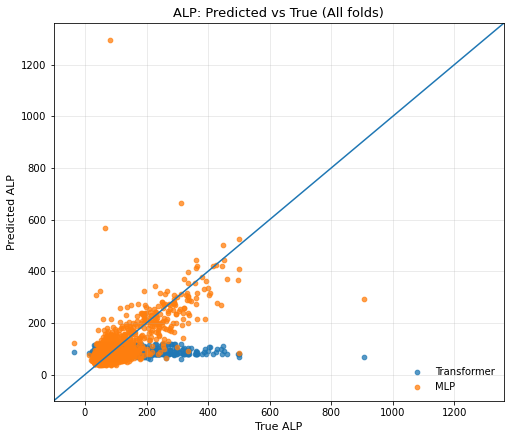

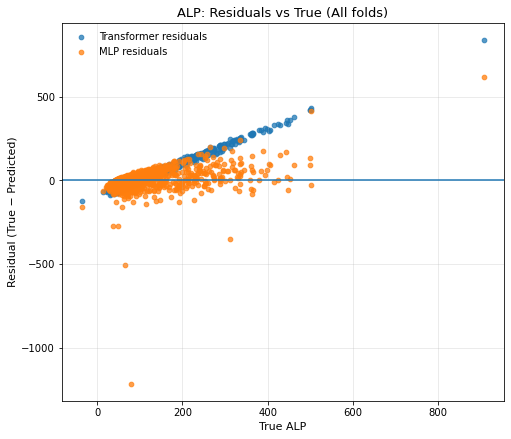

Saved figures:
 - /Users/doreennoldajehu-appiah/Desktop/DEE_NCAT_Work/PhD.Docs/COURSES_semesters/SPRING2026/Deep_Learning/mixture_transformer_run_20260124_223125/outcome=ALP/alp_pred_vs_true_all_folds.png
 - /Users/doreennoldajehu-appiah/Desktop/DEE_NCAT_Work/PhD.Docs/COURSES_semesters/SPRING2026/Deep_Learning/mixture_transformer_run_20260124_223125/outcome=ALP/alp_residuals_all_folds.png


In [47]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# ---- Load ----
path = Path("/Users/doreennoldajehu-appiah/Desktop/DEE_NCAT_Work/PhD.Docs/COURSES_semesters/SPRING2026/Deep_Learning/mixture_transformer_run_20260124_223125/outcome=ALP/predictions_all_folds_ALP.csv")
df = pd.read_csv(path)

# Expected columns from your pipeline:
# fold, y_true, y_pred_transformer, y_pred_mlp
required = {"fold", "y_true", "y_pred_transformer", "y_pred_mlp"}
missing = required - set(df.columns)
if missing:
    raise ValueError(f"Missing columns: {missing}. Found: {list(df.columns)}")

y = df["y_true"].to_numpy()
p_t = df["y_pred_transformer"].to_numpy()
p_m = df["y_pred_mlp"].to_numpy()

# ---- Helper: nice axis limits + parity line ----
def parity_limits(a, b, pad=0.05):
    lo = np.nanmin([a.min(), b.min()])
    hi = np.nanmax([a.max(), b.max()])
    r = hi - lo if hi > lo else 1.0
    lo -= pad * r
    hi += pad * r
    return lo, hi

# =========================
# FIG 1: Predicted vs True
# =========================
plt.figure(figsize=(7.2, 6.2))

# Scatter: Transformer + MLP (default matplotlib colors)
plt.scatter(y, p_t, s=22, alpha=0.75, label="Transformer")
plt.scatter(y, p_m, s=22, alpha=0.75, label="MLP")

# Parity (y=x) line
lo, hi = parity_limits(np.concatenate([y, y]), np.concatenate([p_t, p_m]))
plt.plot([lo, hi], [lo, hi], linewidth=1.5)

plt.title("ALP: Predicted vs True (All folds)", fontsize=13)
plt.xlabel("True ALP", fontsize=11)
plt.ylabel("Predicted ALP", fontsize=11)
plt.xlim(lo, hi)
plt.ylim(lo, hi)
plt.grid(True, linewidth=0.6, alpha=0.4)
plt.legend(frameon=False)
plt.tight_layout()

from pathlib import Path

out1 = Path(
    "/Users/doreennoldajehu-appiah/Desktop/DEE_NCAT_Work/PhD.Docs/COURSES_semesters/SPRING2026/Deep_Learning/mixture_transformer_run_20260124_223125/outcome=ALP"
) / "alp_pred_vs_true_all_folds.png"
plt.savefig(out1, dpi=300)
plt.show()

# =========================
# FIG 2: Residuals vs True
# =========================
res_t = y - p_t
res_m = y - p_m

plt.figure(figsize=(7.2, 6.2))
plt.scatter(y, res_t, s=22, alpha=0.75, label="Transformer residuals")
plt.scatter(y, res_m, s=22, alpha=0.75, label="MLP residuals")
plt.axhline(0, linewidth=1.5)

plt.title("ALP: Residuals vs True (All folds)", fontsize=13)
plt.xlabel("True ALP", fontsize=11)
plt.ylabel("Residual (True − Predicted)", fontsize=11)
plt.grid(True, linewidth=0.6, alpha=0.4)
plt.legend(frameon=False)
plt.tight_layout()

out2 = Path(
    "/Users/doreennoldajehu-appiah/Desktop/DEE_NCAT_Work/PhD.Docs/COURSES_semesters/SPRING2026/Deep_Learning/mixture_transformer_run_20260124_223125/outcome=ALP"
) / "alp_residuals_all_folds.png"
plt.savefig(out2, dpi=300)
plt.show()

print("Saved figures:")
print(" -", out1)
print(" -", out2)